# SIV Project: Board Game Analysis
**Students:** Federico Berra and Davide Verzotto

## Environment Setup & Tools
This section imports the required libraries and defines utility functions for image visualization. These helper functions are used throughout the notebook to display intermediate and final processing results. The loaded image serves as the starting point for the board detection pipeline.

Setup Complete. Tools are ready!
Loaded: 004.png


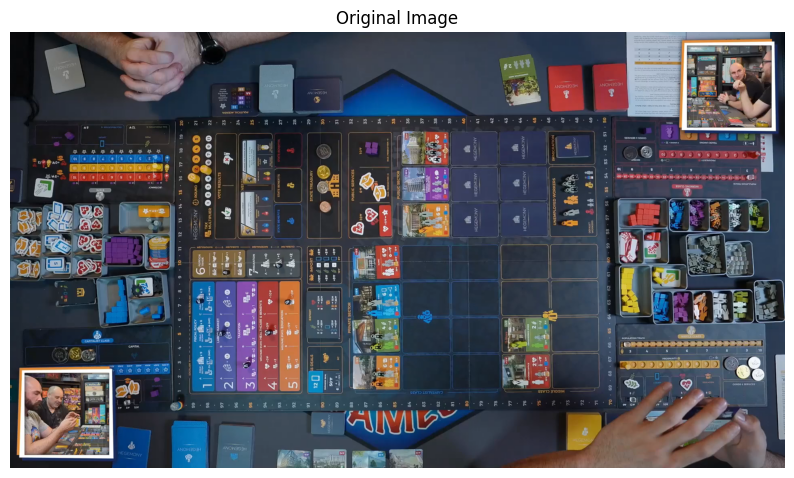

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10,8))

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


folder_path = "../dataset/Game_1/"

image_name = sorted(os.listdir(folder_path))[1]
img_path = os.path.join(folder_path, image_name)
img = cv2.imread(img_path)

print("Setup Complete. Tools are ready!")
print("Loaded:", image_name)
show_image(img, "Original Image")

## Preprocessing
A 2x3 grid is plotted to compare three different preprocessing pipelines alongside their corresponding intensity histograms. This visualization step demonstrates that a direct median filter suppresses internal textures and text without amplifying lighting reflections, improving the robustness of subsequent edge detection

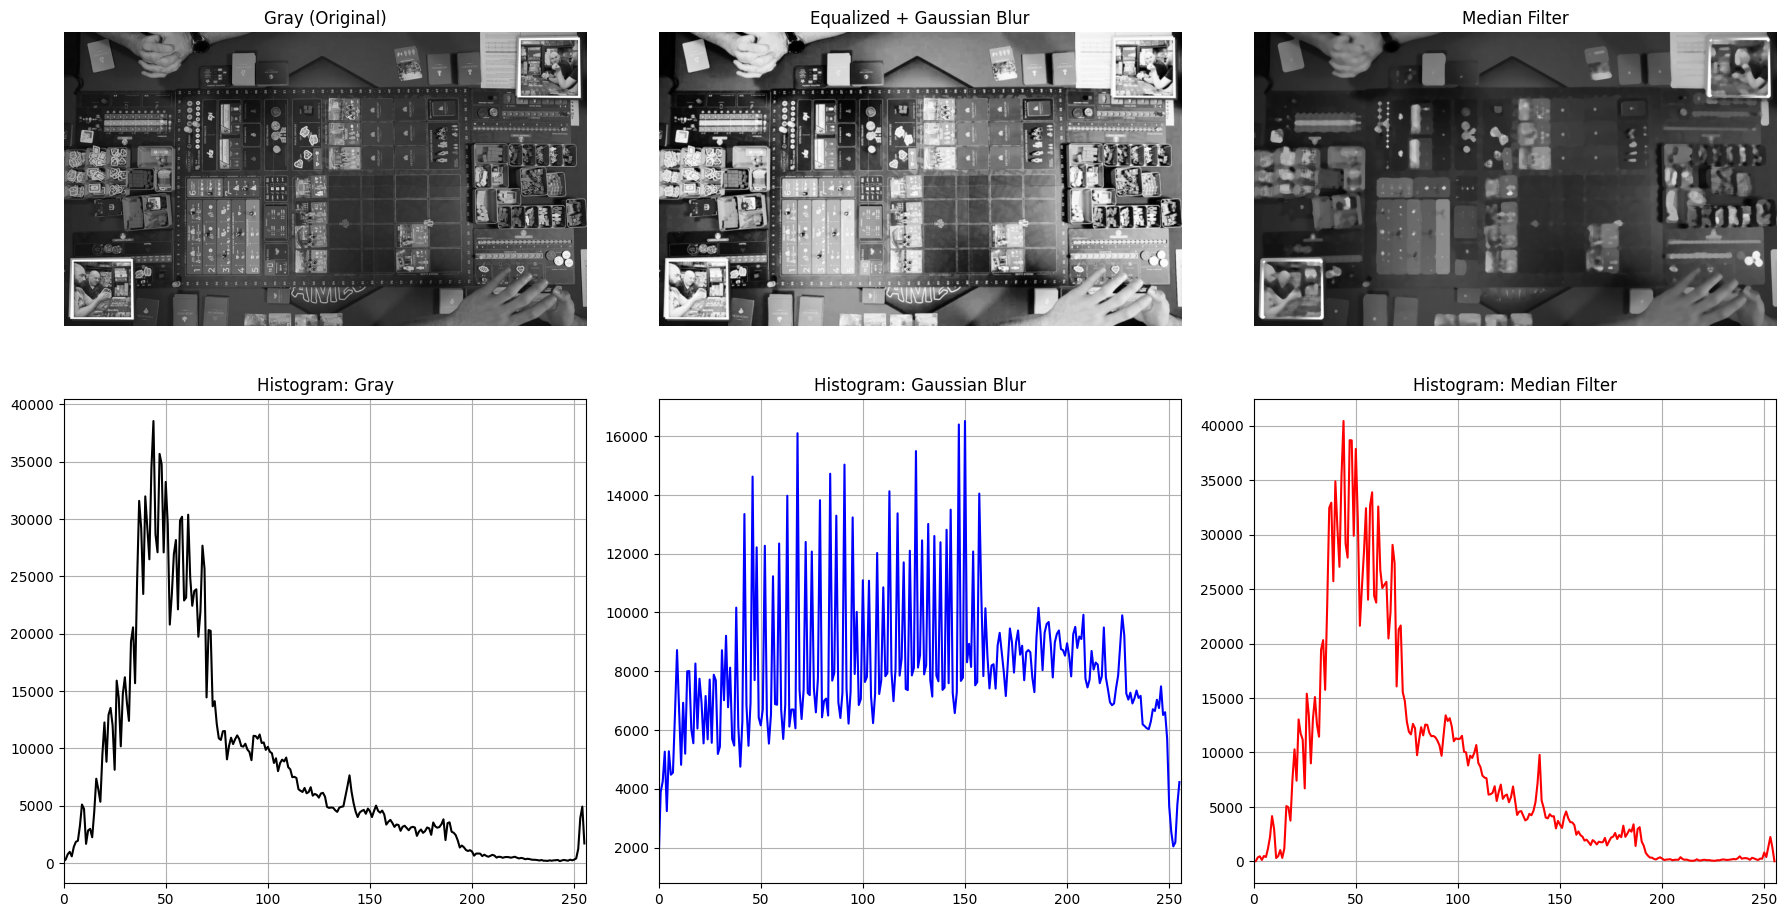

In [60]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)
blur_gaussian = cv2.GaussianBlur(equalized, (5, 5), 0)
blur_median = cv2.medianBlur(gray, 15)

hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_gaussian = cv2.calcHist([blur_gaussian], [0], None, [256], [0, 256])
hist_median = cv2.calcHist([blur_median], [0], None, [256], [0, 256])

# Display
plt.figure(figsize=(18, 10))

# Images
plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Gray (Original)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(blur_gaussian, cmap='gray')
plt.title("Equalized + Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(blur_median, cmap='gray')
plt.title("Median Filter")
plt.axis("off")

# Histogrames
plt.subplot(2, 3, 4)
plt.plot(hist_gray, color='black')
plt.title("Histogram: Gray")
plt.xlim([0, 256])
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(hist_gaussian, color='blue')
plt.title("Histogram: Gaussian Blur")
plt.xlim([0, 256])
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(hist_median, color='red')
plt.title("Histogram: Median Filter")
plt.xlim([0, 256])
plt.grid(True)

plt.tight_layout()
plt.show()

## Edge Detection 
The Canny edge detector is applied to identify significant intensity transitions in the image. These edges provide the structural information required for line detection and board boundary estimation.

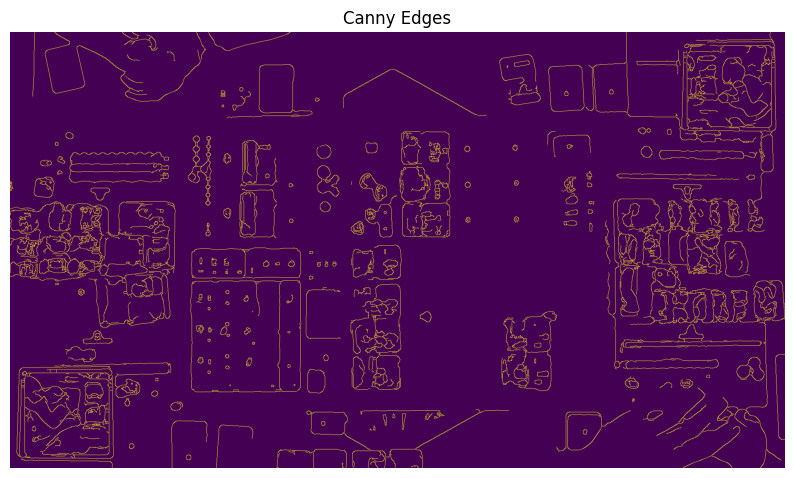

In [56]:
edges = cv2.Canny(blur_median, 30, 100)

show_image(edges, "Canny Edges") # if you want black and white use (...,cmap='gray')

## Hough Transform
The Probabilistic Hough Transform is used to detect straight line segments from the edge map. The detected lines represent candidate boundaries and geometric structures present in the scene.

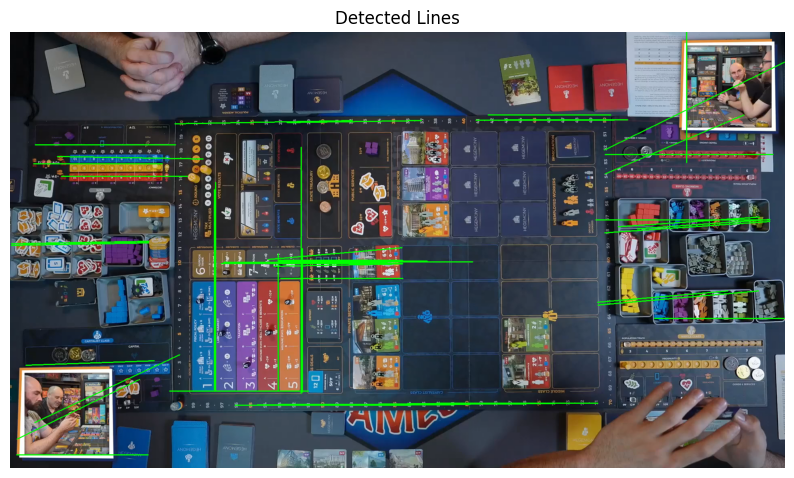

In [49]:
kernel_morph = np.ones((3, 3), np.uint8)
edges_cleaned = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_morph)

lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=100, minLineLength=300, maxLineGap=20)

line_img = img.copy()

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]

        cv2.line(line_img, (x1,y1), (x2,y2), (0,255,0), 2)

show_image(line_img, "Detected Lines")

## Line Orientation Classification
Detected line segments are classified according to their orientation. Horizontal and vertical lines are separated based on their angle, allowing the identification of the potential board boundaries.

In [31]:
horizontal_lines = []
vertical_lines = []

for line in lines:
    x1,y1,x2,y2 = line[0]
    angle = np.degrees(np.arctan2(y2-y1, x2-x1))

    if abs(angle) < 20:
        horizontal_lines.append((x1,y1,x2,y2))

    elif abs(angle) > 70:
        vertical_lines.append((x1,y1,x2,y2))

print("Horizontal:", len(horizontal_lines))
print("Vertical:", len(vertical_lines))

Horizontal: 38
Vertical: 6


## Visualization of Classified Lines
The classified horizontal and vertical line segments are displayed on top of the original image. This visualization provides a qualitative assessment of the line detection process.

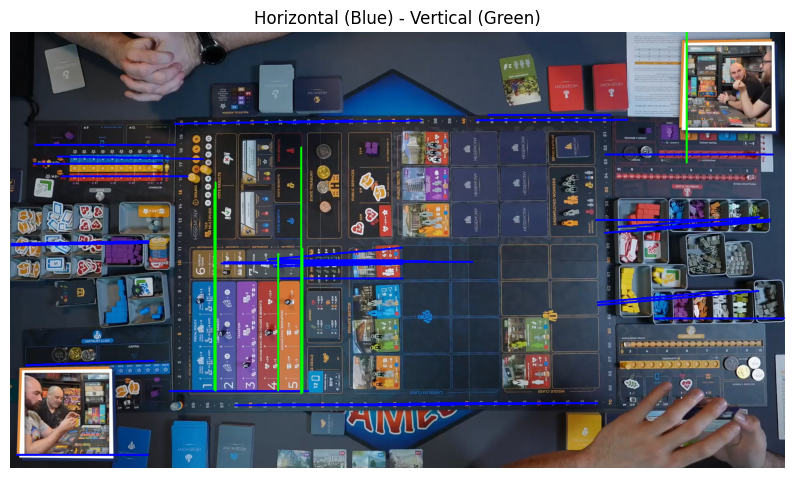

In [32]:
debug = img.copy()

for x1,y1,x2,y2 in horizontal_lines:
    cv2.line(debug, (x1,y1), (x2,y2), (255,0,0), 3)

for x1,y1,x2,y2 in vertical_lines:
    cv2.line(debug, (x1,y1), (x2,y2), (0,255,0), 3)

show_image(debug, "Horizontal (Blue) - Vertical (Green)")

## Board Border Selection
Among the detected horizontal and vertical lines, the outermost candidates are selected as potential board borders. These lines approximate the top, bottom, left, and right boundaries of the game board.

In [33]:
top_line = min(horizontal_lines, key=lambda l: (l[1] + l[3]) / 2)

bottom_line = max(horizontal_lines, key=lambda l: (l[1] + l[3]) / 2)

left_line = min(vertical_lines, key=lambda l: (l[0] + l[2]) / 2)

right_line = max(vertical_lines, key=lambda l: (l[0] + l[2]) / 2)

print("Top:", top_line)
print("Bottom:", bottom_line)
print("Left:", left_line)
print("Right:", right_line)

Top: (np.int32(1184), np.int32(205), np.int32(1488), np.int32(205))
Bottom: (np.int32(16), np.int32(1047), np.int32(342), np.int32(1047))
Left: (np.int32(506), np.int32(886), np.int32(506), np.int32(390))
Right: (np.int32(1676), np.int32(323), np.int32(1676), np.int32(0))


## Board Border Visualization, Line Intersection Computation and Corner Extraction
The selected boundary lines are overlaid on the original image to verify whether they correctly describe the perimeter of the game board. The intersections between the selected boundary lines are computed. These intersections correspond to the four corner points of the detected board. The four board corners are assembled into a point set defining the board geometry. These points are later used to estimate the perspective transformation.

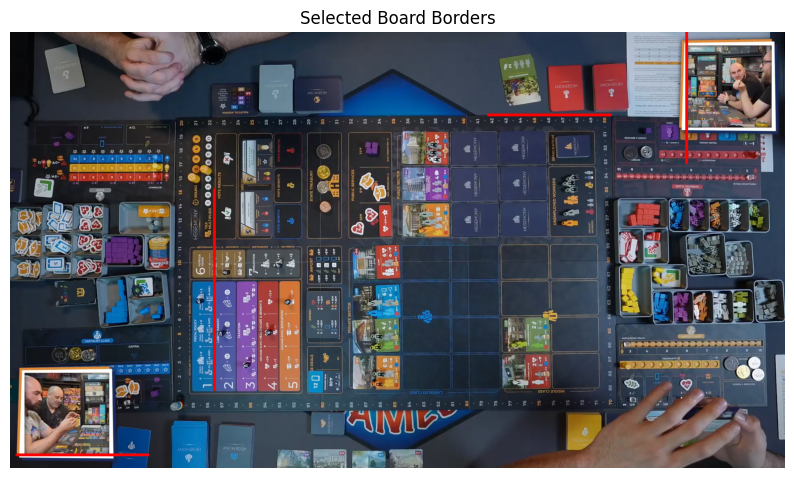

[[ 506.  205.]
 [1676.  205.]
 [1676. 1047.]
 [ 506. 1047.]]


In [34]:
board_lines = img.copy()

for line in [top_line, bottom_line, left_line, right_line]:
    x1,y1,x2,y2 = line
    cv2.line(board_lines, (x1,y1), (x2,y2), (0,0,255), 5)

show_image(board_lines, "Selected Board Borders")

board_lines = img.copy()

def line_intersection(line1, line2):

    x1,y1,x2,y2 = line1
    x3,y3,x4,y4 = line2

    A1 = y2 - y1
    B1 = x1 - x2
    C1 = A1*x1 + B1*y1

    A2 = y4 - y3
    B2 = x3 - x4
    C2 = A2*x3 + B2*y3

    det = A1*B2 - A2*B1

    if abs(det) < 1e-10:
        return None

    x = (B2*C1 - B1*C2) / det
    y = (A1*C2 - A2*C1) / det

    return [x,y]

TL = line_intersection(top_line, left_line)
TR = line_intersection(top_line, right_line)
BR = line_intersection(bottom_line, right_line)
BL = line_intersection(bottom_line, left_line)

src_pts = np.float32([TL, TR, BR, BL])

print(src_pts)

## Final Rectification
A perspective transformation is computed using the detected corner points. The resulting image provides a top-down rectified view of the game board, enabling consistent geometric analysis across different images.

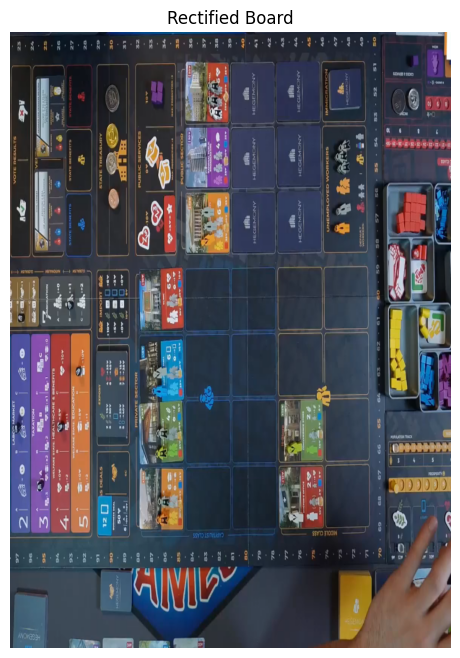

In [35]:
def get_rectified_view(image, src_pts, w, h):

    dst_pts = np.float32([[0,0], [w,0], [w,h], [0,h]])

    M = cv2.getPerspectiveTransform(src_pts, dst_pts)

    return cv2.warpPerspective(image, M, (w,h))

rectified = get_rectified_view(img, src_pts, 1000, 1400)

show_image(rectified, "Rectified Board")